In [1]:
!pip install pytorch_lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 18.6 MB/s eta 0:00:00


In [2]:
!pip install nervaluate

In [3]:
!pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=d12f5537f4bec78380a0a457fe36399e776c12e6937b02fb0999b3fe75cf8644
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [33]:
import os, json, torch
from torch.utils.data.dataset import Dataset
from torch.utils.data import DataLoader
import pytorch_lightning as pl
from transformers import AutoTokenizer, AutoModelForTokenClassification, set_seed
from pytorch_lightning.callbacks import EarlyStopping
from nervaluate import Evaluator
import pandas as pd
from seqeval.metrics import classification_report

In [5]:
CKPT_DIR = f"/content/drive/MyDrive/rodi_study/checkpoints"
RES_DIR  = f"./results"
PRED_DIR = f"./predictions"
datasets_path = './datasets/'

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Evaluate.py

In [7]:
import os, json, torch
from torch.utils.data.dataset import Dataset
from torch.utils.data import DataLoader
import pytorch_lightning as pl
from transformers import AutoTokenizer, AutoModelForTokenClassification, set_seed
from pytorch_lightning.callbacks import EarlyStopping
from nervaluate import Evaluator
import pandas as pd

class TransformerModel(pl.LightningModule):
    def __init__(self, model_name, tokenizer, lr, lr_factor, lr_patience, model_max_length, bio2tags, tag_list):
        super().__init__()
        self.validation_step_outputs = []
        self.test_step_outputs = []

        print("Loading AutoModel [{}] ...".format(model_name))
        self.tokenizer = tokenizer
        self.model = AutoModelForTokenClassification.from_pretrained(model_name, num_labels=len(bio2tags), from_flax=False)

        self.lr = lr
        self.lr_factor = lr_factor
        self.lr_patience = lr_patience
        self.model_max_length = model_max_length
        self.bio2tags = bio2tags
        self.tag_list = tag_list
        self.num_labels = len(bio2tags)

        # add pad token
        self.validate_pad_token()

    def validate_pad_token(self):
        if self.tokenizer.pad_token is not None:
            return
        if self.tokenizer.sep_token is not None:
            print(f"\tNo PAD token detected, automatically assigning the SEP token as PAD.")
            self.tokenizer.pad_token = self.tokenizer.sep_token
            return
        if self.tokenizer.eos_token is not None:
            print(f"\tNo PAD token detected, automatically assigning the EOS token as PAD.")
            self.tokenizer.pad_token = self.tokenizer.eos_token
            return
        if self.tokenizer.bos_token is not None:
            print(f"\tNo PAD token detected, automatically assigning the BOS token as PAD.")
            self.tokenizer.pad_token = self.tokenizer.bos_token
            return
        if self.tokenizer.cls_token is not None:
            print(f"\tNo PAD token detected, automatically assigning the CLS token as PAD.")
            self.tokenizer.pad_token = self.tokenizer.cls_token
            return
        raise Exception(
            "Could not detect SEP/EOS/BOS/CLS tokens, and thus could not assign a PAD token which is required.")

    def forward(self, input_ids, attention_mask, labels):
        output = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
            return_dict=True
        )
        return output["loss"], output["logits"]

    def training_step(self, batch, batch_idx):
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["labels"]

        loss, _ = self(input_ids, attention_mask, labels)
        return {"loss": loss}

    def validation_step(self, batch, batch_idx):
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["labels"]
        token_idx = batch["token_idx"]

        loss, logits = self(input_ids, attention_mask, labels)  # logits is [batch_size, seq_len, num_classes]

        batch_size = logits.size()[0]
        batch_pred = torch.argmax(logits.detach().cpu(), dim=-1).tolist()  # reduce to [batch_size, seq_len] as list
        batch_gold = labels.detach().cpu().tolist()  # [batch_size, seq_len] as list
        batch_token_idx = token_idx.detach().cpu().tolist()

        for batch_idx in range(batch_size):
            pred, gold, idx = batch_pred[batch_idx], batch_gold[batch_idx], batch_token_idx[batch_idx]
            y_hat, y = [], []
            for i in range(0, max(idx) + 1): # for each sentence
                pos = idx.index(i)  # find next token index and get pred and gold
                y_hat.append(pred[pos])
                y.append(gold[pos])

        self.validation_step_outputs.append({
            "loss": loss,
            "y": y,
            "y_hat": y_hat
        })

        return {
            "loss": loss,
            "y": y,
            "y_hat": y_hat
        }

    def on_validation_epoch_end(self):
        odf = pd.DataFrame(self.validation_step_outputs)

        mean_val_loss = odf["loss"].mean()
        gold, pred = [], []
        for _, row in odf.iterrows():
            gold.append([self.bio2tags[token_id] for token_id in row["y"]])
            pred.append([self.bio2tags[token_id] for token_id in row["y_hat"]])

        evaluator = Evaluator(gold, pred, tags=self.tag_list, loader="list")

        results, _ = evaluator.evaluate()
        self.log("valid/avg_loss", mean_val_loss, prog_bar=True)
        self.log("valid/ent_type", float(results["ent_type"]["f1"]))
        self.log("valid/partial", float(results["partial"]["f1"]))
        self.log("valid/strict", float(results["strict"]["f1"]), prog_bar=True)
        self.log("valid/exact", float(results["exact"]["f1"]))

        self.validation_step_outputs.clear()

    def test_step(self, batch, batch_idx):
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["labels"]
        token_idx = batch["token_idx"]

        loss, logits = self(input_ids, attention_mask, labels)  # logits is [batch_size, seq_len, num_classes]

        batch_size = logits.size()[0]
        batch_pred = torch.argmax(logits.detach().cpu(), dim=-1).tolist()  # reduce to [batch_size, seq_len] as list
        batch_gold = labels.detach().cpu().tolist()  # [batch_size, seq_len] as list
        batch_token_idx = token_idx.detach().cpu().tolist()

        for batch_idx in range(batch_size):
            pred, gold, idx = batch_pred[batch_idx], batch_gold[batch_idx], batch_token_idx[batch_idx]
            y_hat, y = [], []
            for i in range(0, max(idx) + 1):  # for each sentence
                pos = idx.index(i)  # find next token index and get pred and gold
                y_hat.append(pred[pos])
                y.append(gold[pos])

        self.test_step_outputs.append({
            "loss": loss,
            "y": y,
            "y_hat": y_hat
        })

        return {
            "loss": loss,
            "y": y,
            "y_hat": y_hat
        }

    def on_test_epoch_end(self):
        odf = pd.DataFrame(self.test_step_outputs)

        mean_val_loss = odf["loss"].mean()
        gold, pred = [], []
        for _, row in odf.iterrows():
            gold.append([self.bio2tags[token_id] for token_id in row["y"]])
            pred.append([self.bio2tags[token_id] for token_id in row["y_hat"]])

        evaluator = Evaluator(gold, pred, tags=self.tag_list, loader="list")

        results, _ = evaluator.evaluate()
        self.log("test/avg_loss", mean_val_loss, prog_bar=True)
        self.log("test/ent_type", results["ent_type"]["f1"])
        self.log("test/partial", results["partial"]["f1"])
        self.log("test/strict", results["strict"]["f1"])
        self.log("test/exact", results["exact"]["f1"])

        self.test_step_outputs.clear()

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW([p for p in self.parameters() if p.requires_grad], lr=self.lr, eps=1e-08)
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer,
                    factor=self.lr_factor,
                    patience=self.lr_patience,
                    mode='max'
                ),
                'interval': 'epoch',
                'frequency': 1,
                'monitor': 'valid/strict',
                'strict': True,
                'name': 'learning_rate',
            },
        }

    def predict(self, input_string):
        input_ids = self.tokenizer.encode(input_string, add_special_tokens=False)

        # run the model
        output = self.model(input_ids=torch.unsqueeze(torch.LongTensor(input_ids), 0), return_dict=True)
        logits = output["logits"]

        # extract results
        indices = torch.argmax(logits.detach().cpu(), dim=-1).squeeze(dim=0).tolist()  # reduce to [batch_size, seq_len] as list

        output_ids = []

        for id in input_ids:
            output_ids.append(self.tokenizer.decode(id))

        output_classes = []
        for i in indices:
            output_classes.append(self.bio2tags[i])

        return output_ids, output_classes


class RoNecDataset(Dataset):
    def __init__(self, instances):
        self.instances = []

        # run check
        for instance in instances:
            ok = True
            if len(instance["ner_ids"]) != len(instance["tokens"]):
                print("Different length ner_tags found")
                ok = False
            else:
                for _, token in zip(instance["ner_ids"], instance["tokens"]):
                    if token.strip() == "":
                        ok = False
                        print("Empty token found")
            if ok:
                self.instances.append(instance)

    def __len__(self):
        return len(self.instances)

    def __getitem__(self, i):
        return self.instances[i]


class Collator(object):
    def __init__(self, tokenizer, max_seq_len):
        self.tokenizer = tokenizer
        self.max_seq_len = max_seq_len

        self.validate_pad_token()

    def validate_pad_token(self):
        if self.tokenizer.pad_token is not None:
            return
        if self.tokenizer.sep_token is not None:
            print(f"\tNo PAD token detected, automatically assigning the SEP token as PAD.")
            self.tokenizer.pad_token = self.tokenizer.sep_token
            return
        if self.tokenizer.eos_token is not None:
            print(f"\tNo PAD token detected, automatically assigning the EOS token as PAD.")
            self.tokenizer.pad_token = self.tokenizer.eos_token
            return
        if self.tokenizer.bos_token is not None:
            print(f"\tNo PAD token detected, automatically assigning the BOS token as PAD.")
            self.tokenizer.pad_token = self.tokenizer.bos_token
            return
        if self.tokenizer.cls_token is not None:
            print(f"\tNo PAD token detected, automatically assigning the CLS token as PAD.")
            self.tokenizer.pad_token = self.tokenizer.cls_token
            return
        raise Exception("Could not detect SEP/EOS/BOS/CLS tokens, and thus could not assign a PAD token which is required.")


    def __call__(self, input_batch):
        batch_input_ids, batch_labels, batch_attention, batch_token_idx = [], [], [], []
        max_len = 0

        for instance in input_batch:
            instance_ids, instance_labels, instance_attention, instance_token_idx = [], [], [], []

            for i in range(len(instance["tokens"])):
                subids = self.tokenizer.encode(instance["tokens"][i], add_special_tokens=False)
                sublabels = [instance["ner_ids"][i]]

                if len(subids) > 1:  # we have a word split in more than 1 subids, fill appropriately
                    filler_sublabel = sublabels[0] if sublabels[0] % 2 == 0 else sublabels[0] + 1
                    sublabels.extend([filler_sublabel] * (len(subids) - 1))

                instance_ids.extend(subids)  # extend with the number of subids
                instance_labels.extend(sublabels)  # extend with the number of subtags
                instance_token_idx.extend([i] * len(subids))  # extend with the id of the token

                assert len(subids) == len(sublabels) # check for possible errors in the dataset

            if len(instance_ids) != len(instance_labels):
                print(len(instance_ids))
                print(len(instance_labels))
                print(instance_ids)
                print(instance_labels)
            assert len(instance_ids) == len(instance_labels)

            # cut to max sequence length, if needed
            if len(instance_ids) > self.max_seq_len - 2:
                instance_ids = instance_ids[:self.max_seq_len - 2]
                instance_labels = instance_labels[:self.max_seq_len - 2]
                instance_token_idx = instance_token_idx[:self.max_seq_len - 2]

            # prepend and append special tokens, if needed
            if self.tokenizer.cls_token_id and self.tokenizer.sep_token_id:
                instance_ids = [self.tokenizer.cls_token_id] + instance_ids + [self.tokenizer.sep_token_id]
                instance_labels = [0] + instance_labels + [0]
                instance_token_idx = [-1] + instance_token_idx  # no need to pad the last, will do so automatically at return
            instance_attention = [1] * len(instance_ids)

            # update max_len for later padding
            max_len = max(max_len, len(instance_ids))

            # add to batch
            batch_input_ids.append(torch.LongTensor(instance_ids))
            batch_labels.append(torch.LongTensor(instance_labels))
            batch_attention.append(torch.LongTensor(instance_attention))
            batch_token_idx.append(torch.LongTensor(instance_token_idx))

        return {
            "input_ids": torch.nn.utils.rnn.pad_sequence(batch_input_ids, batch_first=True, padding_value=self.tokenizer.pad_token_id if self.tokenizer.pad_token_id else 0),
            "attention_mask": torch.nn.utils.rnn.pad_sequence(batch_attention, batch_first=True, padding_value=0),
            "labels": torch.nn.utils.rnn.pad_sequence(batch_labels, batch_first=True, padding_value=0),
            "token_idx": torch.nn.utils.rnn.pad_sequence(batch_token_idx, batch_first=True, padding_value=-1)
        }


def run_evaluation(args):
    print("Loading data...")
    with open(args.train_file, "r", encoding="utf8") as f:
        train_data = json.load(f)
    with open(args.validation_file, "r", encoding="utf8") as f:
        validation_data = json.load(f)
    with open(args.test_file, "r", encoding="utf8") as f:
        test_data = json.load(f)

    # deduce bio2 tag mapping and simple tag list, required by nervaluate
    # deduce bio2 tag mapping and simple tag list, required by nervaluate
    tags = ["O"] * 16  # tags without the B- or I- prefix
    bio2tags = ["O"] * 31  # tags with the B- and I- prefix, all tags are here

    for instance in train_data:
        for tag, tag_index in zip(instance["ner_tags"], instance["ner_ids"]):
            bio2tags[tag_index] = tag  # put the bio2 tag in its correct position
            if tag_index % 2 == 0 and tag_index > 0:
                tags[int(tag_index / 2)] = tag[2:]

    print(f"\tDataset contains {len(bio2tags)} BIO2 classes: {bio2tags}.")
    print(f"\tThere are {len(tags)} classes: {tags}\n")

    # init tokenizer and start loading data
    tokenizer = AutoTokenizer.from_pretrained(args.model_name, strip_accents=False)
    train_dataset = RoNecDataset(train_data)
    val_dataset = RoNecDataset(validation_data)
    test_dataset = RoNecDataset(test_data)

    collator = Collator(tokenizer=tokenizer, max_seq_len=args.model_max_length)

    train_dataloader = DataLoader(train_dataset, batch_size=args.batch_size, num_workers=4, shuffle=True,
                                  collate_fn=collator, pin_memory=True)
    val_dataloader = DataLoader(val_dataset, batch_size=args.batch_size, num_workers=4, shuffle=False,
                                collate_fn=collator, pin_memory=True)
    test_dataloader = DataLoader(test_dataset, batch_size=args.batch_size, num_workers=4, shuffle=False,
                                 collate_fn=collator, pin_memory=True)

    print("\tTrain dataset has {} instances.".format(len(train_dataset)))
    print("\tValid dataset has {} instances.".format(len(val_dataset)))
    print("\tTest dataset has {} instances.\n".format(len(test_dataset)))

    itt = 0

    valid_loss = []
    valid_ent_type = []
    valid_partial = []
    valid_strict = []
    valid_exact = []
    test_loss = []
    test_ent_type = []
    test_partial = []
    test_strict = []
    test_exact = []
    while itt < args.experiment_iterations:
        print("Running experiment {}/{}".format(itt + 1, args.experiment_iterations))

        model = TransformerModel(
            model_name=args.model_name,
            lr=args.lr,
            lr_factor=args.lr_factor,
            lr_patience=args.lr_patience,
            model_max_length=args.model_max_length,
            bio2tags=bio2tags,
            tokenizer=tokenizer,
            tag_list=tags,
        )

        early_stop = EarlyStopping(
            monitor='valid/strict',
            min_delta=0.0001,
            patience=5,
            verbose=True,
            mode='max'
        )

        lr_monitor = pl.callbacks.LearningRateMonitor(logging_interval='epoch')

        model_checkpointer = pl.callbacks.ModelCheckpoint(save_top_k=1, monitor='valid/strict', dirpath=args.dirpath,
                                                          filename='{epoch}', mode='max', save_on_train_epoch_end=True)

        trainer = pl.Trainer(
            accelerator='gpu',
            devices=args.devices,
            strategy=args.strategy,
            max_epochs=args.max_epochs,
            callbacks=[lr_monitor, early_stop, model_checkpointer],
            accumulate_grad_batches=args.accumulate_grad_batches,
            gradient_clip_val=1.0,
            #limit_train_batches=50,
            #limit_val_batches=50,
        )
        trainer.fit(model, train_dataloader, val_dataloader)

        print("\nEvaluating model on the VALIDATION dataset:")
        result_valid = trainer.test(model, val_dataloader)
        print("\nEvaluating model on the TEST dataset:")
        result_test = trainer.test(model, test_dataloader)

        with open("results_ronec_{}_of_{}.json".format(itt + 1, args.experiment_iterations), "w") as f:
            json.dump(result_test[0], f, indent=4, sort_keys=True)

        valid_loss.append(result_valid[0]['test/avg_loss'])
        valid_ent_type.append(result_valid[0]['test/ent_type'])
        valid_partial.append(result_valid[0]['test/partial'])
        valid_strict.append(result_valid[0]['test/strict'])
        valid_exact.append(result_valid[0]['test/exact'])
        test_loss.append(result_test[0]['test/avg_loss'])
        test_ent_type.append(result_test[0]['test/ent_type'])
        test_partial.append(result_test[0]['test/partial'])
        test_strict.append(result_test[0]['test/strict'])
        test_exact.append(result_test[0]['test/exact'])

        itt += 1

    print("Done, writing results...\n")

    result = {
        "valid_loss": sum(valid_loss) / args.experiment_iterations,
        "valid_ent_type": sum(valid_ent_type) / args.experiment_iterations,
        "valid_partial": sum(valid_partial) / args.experiment_iterations,
        "valid_strict": sum(valid_strict) / args.experiment_iterations,
        "valid_exact": sum(valid_exact) / args.experiment_iterations,
        "test_loss": sum(test_loss) / args.experiment_iterations,
        "test_ent_type": sum(test_ent_type) / args.experiment_iterations,
        "test_partial": sum(test_partial) / args.experiment_iterations,
        "test_strict": sum(test_strict) / args.experiment_iterations,
        "test_exact": sum(test_exact) / args.experiment_iterations
    }

    with open("results_{}.json".format(args.model_name.replace("/", "_")), "w") as f:
        json.dump(result, f, indent=4, sort_keys=True)

    print("\nFinal averaged results on TEST data: ")
    from pprint import pprint
    pprint(result)


# Load tags

In [9]:
with open(datasets_path + 'diac/train.json', "r", encoding="utf8") as f:
    train_diac = json.load(f)

In [10]:
tags = ["O"] * 16  # tags without the B- or I- prefix
bio2tags = ["O"] * 31  # tags with the B- and I- prefix

for instance in train_diac:
    for tag, tag_index in zip(instance["ner_tags"], instance["ner_ids"]):
        bio2tags[tag_index] = tag  # put the bio2 tag in its correct position
        if tag_index % 2 == 0 and tag_index > 0:
            tags[int(tag_index / 2)] = tag[2:]

In [11]:
print(tags)

['O', 'PERSON', 'ORG', 'GPE', 'LOC', 'NAT_REL_POL', 'EVENT', 'LANGUAGE', 'WORK_OF_ART', 'DATETIME', 'PERIOD', 'MONEY', 'QUANTITY', 'NUMERIC', 'ORDINAL', 'FACILITY']


In [12]:
print(bio2tags)

['O', 'B-PERSON', 'I-PERSON', 'B-ORG', 'I-ORG', 'B-GPE', 'I-GPE', 'B-LOC', 'I-LOC', 'B-NAT_REL_POL', 'I-NAT_REL_POL', 'B-EVENT', 'I-EVENT', 'B-LANGUAGE', 'I-LANGUAGE', 'B-WORK_OF_ART', 'I-WORK_OF_ART', 'B-DATETIME', 'I-DATETIME', 'B-PERIOD', 'I-PERIOD', 'B-MONEY', 'I-MONEY', 'B-QUANTITY', 'I-QUANTITY', 'B-NUMERIC', 'I-NUMERIC', 'B-ORDINAL', 'I-ORDINAL', 'B-FACILITY', 'I-FACILITY']


# Load test dataset

In [13]:
with open(datasets_path + 'diac/test.json', "r", encoding="utf8") as f:
    test_diac = json.load(f)
with open(datasets_path + 'nodiac/test.json', "r", encoding="utf8") as f:
    test_nodiac = json.load(f)

# Load model

In [14]:
# ── Load best checkpoint ────────────────────────────────────
model_name = "bert-base-multilingual-cased" # @param ["dumitrescustefan/bert-base-romanian-cased-v1","bert-base-multilingual-cased","google/mt5-base","google/rembert"] {"allow-input":true}
TRAIN_COND = "diac" # @param ["diac", "nodiac"] {"allow-input":true}
iteration_no = "first" # @param ["first", "second", "third"] {"allow-input":true}
best_ckpt = "epoch=2_it1.ckpt" # @param {"allow-input":true}
print(f"Best checkpoint: {best_ckpt}")

Best checkpoint: epoch=2_it1.ckpt


In [15]:
model = TransformerModel.load_from_checkpoint(
    CKPT_DIR + '/' + best_ckpt,
    weights_only=True,
    model_name=model_name,
    tokenizer=AutoTokenizer.from_pretrained(model_name),
    lr=2e-05,
    lr_factor=2/3,
    lr_patience=5,
    model_max_length=768,
    bio2tags=bio2tags,
    tag_list=tags
)
model.eval()
model.cuda()

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Loading AutoModel [bert-base-multilingual-cased] ...


model.safetensors: reconstructing file:   0%|          |  0.00B /  714MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params

TransformerModel(
  (model): BertForTokenClassification(
    (bert): BertModel(
      (embeddings): BertEmbeddings(
        (word_embeddings): Embedding(119547, 768, padding_idx=0)
        (position_embeddings): Embedding(512, 768)
        (token_type_embeddings): Embedding(2, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): BertEncoder(
        (layer): ModuleList(
          (0-11): 12 x BertLayer(
            (attention): BertAttention(
              (self): BertSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): BertSelfOutput(
                (dense): Linear(in_features=768, out_features=768,

# Crossed Inference

## Used functions

In [25]:
def run_inference(model, dataloader, bio2tags, device="cuda"):
    """
    Mirrors the evaluate script's validation_step logic but
    stores per-sentence results instead of aggregating them.
    Returns a list of dicts: {tokens, gold_tags, pred_tags}
    """
    model.eval()
    records = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids_key, attention_mask_key, labels_key, batch_token_idx_key = batch
            input_ids      = batch[input_ids_key].to(device)
            attention_mask = batch[attention_mask_key].to(device)
            labels_tensor  = batch[labels_key].to(device)

            outputs = model(input_ids, attention_mask, labels_tensor)   # (B, seq_len, num_labels)
            logits  = outputs[1]
            preds  = torch.argmax(logits, dim=-1).cpu().numpy()
            labels = batch[labels_key].cpu().numpy()

            for sent_preds, sent_labels, token_idx in zip(preds, labels, batch[batch_token_idx_key]):
                # token_idx: list of subword positions for each word
                word_preds  = [sent_preds[idx]  for idx in token_idx]
                word_labels = [sent_labels[idx]  for idx in token_idx]

                # Decode integer ids → tag strings
                pred_tags = [bio2tags[i] for i in word_preds]
                gold_tags = [bio2tags[i] for i in word_labels]

                records.append({
                    "pred_tags": pred_tags,
                    "gold_tags": gold_tags,
                })

    return records

In [29]:
def eval_model(model_name, model, bio2tags):
    results = []
    for eval_cond, test_dataset in [("diac", test_diac), ("nodiac", test_nodiac)]:
        tokenizer = AutoTokenizer.from_pretrained(model_name, strip_accents=False)
        collator = Collator(tokenizer=tokenizer, max_seq_len=512)

        test_loader = DataLoader(test_dataset, batch_size=batch_size, num_workers=4, shuffle=False,
                                     collate_fn=collator, pin_memory=True)


        records = run_inference(model, test_loader, bio2tags, "cuda")

        # ── Save raw predictions ────────────────────────────────
        pred_path = f"{PRED_DIR}/{RUN_NAME}_eval_{eval_cond}.json"
        with open(pred_path, "w", encoding="utf-8") as f:
            json.dump(records, f, ensure_ascii=False, indent=2)

        # ── Per-class seqeval report ────────────────────────────
        golds = [r["gold_tags"] for r in records]
        preds = [r["pred_tags"] for r in records]

        report = classification_report(golds, preds, output_dict=True, zero_division=0)
        df = pd.DataFrame(report).T
        df.to_csv(f"{RES_DIR}/{RUN_NAME}_eval_{eval_cond}_per_class.csv")
        print(f"\n=== {RUN_NAME} → eval {eval_cond} ===")
        print(df.to_string())
        results.append((df, records))
    return tuple(results)

## Run inference

In [27]:
# Configs
batch_size = 8

MODEL_KEY = {
    "dumitrescustefan/bert-base-romanian-cased-v1": "robert",
    "bert-base-multilingual-cased": "mbert",
    "google/mt5-base": "mt5",
    "google/rembert": "rembert"
}[model_name]

RUN_NAME = f"{MODEL_KEY}_train_{TRAIN_COND}"

SEED = {
    "first": 315,
    "second": 222,
    "third": 156
}[iteration_no]

print("Run name: " + RUN_NAME)
print("Seed: " + str(SEED))

BASE     = f"/content/drive/MyDrive/rodi_study/{RUN_NAME}"


Run name: mbert_train_diac
Seed: 315


In [34]:
rows = []
(df_diac, diac_records), (df_nodiac, nodiac_records) = eval_model(model_name, model, bio2tags)

row = df_diac.loc["micro avg"] if "micro avg" in df_diac.index else df_diac.loc["weighted avg"]
rows.append({"run": MODEL_KEY + '_' + TRAIN_COND + '_' + iteration_no, "eval": 'diac',
                 "P": round(row["precision"],4),
                 "R": round(row["recall"],4),
                 "F1": round(row["f1-score"],4)})

row = df_nodiac.loc["micro avg"] if "micro avg" in df_nodiac.index else df_nodiac.loc["weighted avg"]
rows.append({"run": MODEL_KEY + '_' + TRAIN_COND + '_' + iteration_no, "eval": 'nodiac',
                 "P": round(row["precision"],4),
                 "R": round(row["recall"],4),
                 "F1": round(row["f1-score"],4)})
print(rows)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



=== mbert_train_diac → eval diac ===
              precision    recall  f1-score  support
DATETIME       0.910386  0.924096  0.917190   1660.0
EVENT          0.582353  0.562500  0.572254    176.0
FACILITY       0.755319  0.533835  0.625551    133.0
GPE            0.905325  0.896484  0.900883   1536.0
LANGUAGE       0.682540  0.781818  0.728814     55.0
LOC            0.686930  0.601064  0.641135    376.0
MONEY          0.879518  0.863905  0.871642    169.0
NAT_REL_POL    0.867097  0.875000  0.871030    768.0
NUMERIC        0.947415  0.950748  0.949078   1137.0
ORDINAL        0.894928  0.678571  0.771875    364.0
ORG            0.771563  0.843773  0.806054   1357.0
PERIOD         0.835897  0.881081  0.857895    185.0
PERSON         0.859098  0.902921  0.880465   4450.0
QUANTITY       0.931937  0.962162  0.946809    185.0
WORK_OF_ART    0.601896  0.526971  0.561947    241.0
micro avg      0.857374  0.869841  0.863562  12792.0
macro avg      0.807480  0.785662  0.793508  12792.0
weighted

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



=== mbert_train_diac → eval nodiac ===
              precision    recall  f1-score  support
DATETIME       0.841637  0.839645  0.840640   1690.0
EVENT          0.493243  0.407821  0.446483    179.0
FACILITY       0.764045  0.485714  0.593886    140.0
GPE            0.874011  0.858161  0.866013   1544.0
LANGUAGE       0.688525  0.736842  0.711864     57.0
LOC            0.605678  0.512000  0.554913    375.0
MONEY          0.864407  0.850000  0.857143    180.0
NAT_REL_POL    0.853825  0.837802  0.845737    746.0
NUMERIC        0.934116  0.927419  0.930755   1116.0
ORDINAL        0.902834  0.652047  0.757216    342.0
ORG            0.739213  0.836324  0.784776   1393.0
PERIOD         0.661538  0.661538  0.661538    195.0
PERSON         0.828664  0.860041  0.844061   4437.0
QUANTITY       0.875000  0.943005  0.907731    193.0
WORK_OF_ART    0.597938  0.453125  0.515556    256.0
micro avg      0.821448  0.822471  0.821959  12843.0
macro avg      0.768312  0.724099  0.741221  12843.0
weight

In [36]:
file_path = "/content/drive/MyDrive/rodi_study/ner_error_analysis/summary_results.csv"

# Check if file exists so we only write headers on the first run
file_exists = os.path.exists(file_path)

err_df = pd.DataFrame(rows)
# Append to the file (header=False if file already exists)
err_df.to_csv(file_path, mode="a", header=not file_exists)

# Error analysis

In [37]:
def categorize_errors(records, run_name, iteration_no, sent_offset=0):
    """
    Takes the records list from run_inference (gold_tags, pred_tags per sentence).
    Returns a DataFrame with one row per span-level error.
    error_type ∈ {missed, spurious, wrong_type, wrong_boundary}
    """

    def get_spans(tags):
        spans, i = {}, 0
        while i < len(tags):
            if tags[i].startswith("B-"):
                label = tags[i][2:]
                j = i + 1
                while j < len(tags) and tags[j] == f"I-{label}":
                    j += 1
                spans[(i, j - 1)] = label
                i = j
            else:
                i += 1
        return spans

    rows = []
    for sid, rec in enumerate(records, start=sent_offset):
        gold_spans = get_spans(rec["gold_tags"])
        pred_spans = get_spans(rec["pred_tags"])

        done_gold, done_pred = set(), set()

        # ─── 1. EXACT MATCHES (True Positives & Wrong Type) ───────────────────
        for pos in set(gold_spans) & set(pred_spans):
            gl, pl = gold_spans[pos], pred_spans[pos]
            if gl != pl:
                rows.append(dict(run_name=run_name, iteration_no=iteration_no,
                                 sent_id=sid, error_type="wrong_type",
                                gold_class=gl, pred_class=pl,
                                gold_span=pos, pred_span=pos))

            # Mark both as handled regardless of label match
            done_gold.add(pos)
            done_pred.add(pos)

        # ─── 2. OVERLAPPING BOUNDARIES (Wrong Boundary) ───────────────────────
        for gpos, gl in gold_spans.items():
            if gpos in done_gold:
                continue

            for ppos, pl in pred_spans.items():
                if ppos in done_pred:
                    continue

                gs, ge = gpos
                ps, pe = ppos

                # Check overlap condition: same class, boundaries intersect, not identical
                if gl == pl and gs <= pe and ps <= ge and gpos != ppos:
                    rows.append(dict(run_name=run_name, iteration_no=iteration_no,
                                     sent_id=sid, error_type="wrong_boundary",
                                    gold_class=gl, pred_class=pl,
                                    gold_span=gpos, pred_span=ppos))
                    done_gold.add(gpos)
                    done_pred.add(ppos)
                    break  # Move to next gold span since this one is resolved

        # ─── 3. CLEAN UP (Missed & Spurious) ──────────────────────────────────
        # Missed (False Negatives)
        for pos, label in gold_spans.items():
            if pos not in done_gold:
                rows.append(dict(run_name=run_name, iteration_no=iteration_no,
                                 sent_id=sid, error_type="missed",
                                gold_class=label, pred_class="O",
                                gold_span=pos, pred_span=None))

        # Spurious (False Positives)
        for pos, label in pred_spans.items():
            if pos not in done_pred:
                rows.append(dict(run_name=run_name, iteration_no=iteration_no,
                                 sent_id=sid, error_type="spurious",
                                gold_class="O", pred_class=label,
                                gold_span=None, pred_span=pos))

    return pd.DataFrame(rows)


file_path = "/content/drive/MyDrive/rodi_study/ner_error_analysis/error_analysis.csv"

for records, eval_cond in zip([diac_records, nodiac_records], ['diac', 'nodiac']):

    errors = categorize_errors(records, RUN_NAME, iteration_no)

    # Check if file exists so we only write headers on the first run
    file_exists = os.path.exists(file_path)

    # Append to the file (header=False if file already exists)
    errors.to_csv(file_path, mode="a", header=not file_exists)

# Final results aggregation

In [38]:
# 1. Count errors per run_name, iteration_no, gold_class, and error_type
error_counts = (
    errors.groupby(["run_name", "iteration_no", "gold_class", "error_type"])
    .size()
    .unstack(fill_value=0)
)

# 2. Get the total number of errors made in each specific (model_id, run)
total_errors = errors.groupby(["run_name", "iteration_no"]).size()

# 3. Calculate Strategy 1: Percentage of total run errors
pct_by_run = error_counts.div(total_errors, axis=0) * 100

# 4. Compute Mean and Standard Deviation across runs for each model_id
mean_pct = pct_by_run.groupby(["run_name", "gold_class"]).mean().round(2)
std_pct = pct_by_run.groupby(["run_name", "gold_class"]).std().round(2)

# 5. Format into a clean "Mean ± Std (%)" table
formatted_summary = (
    mean_pct.astype(str) + "% ± " + std_pct.fillna(0).astype(str) + "%"
)

In [39]:
# Loop through all models and save individual CSV files
for run_name in errors["run_name"].unique():
    model_table = formatted_summary.loc[run_name]
    model_table.to_csv(f"/content/drive/MyDrive/rodi_study/ner_error_analysis/error_analysis_{run_name}.csv")

In [40]:
# Save all models into one CSV with multi-level row headers
formatted_summary.to_csv("/content/drive/MyDrive/rodi_study/ner_error_analysis/all_models_error_analysis.csv")

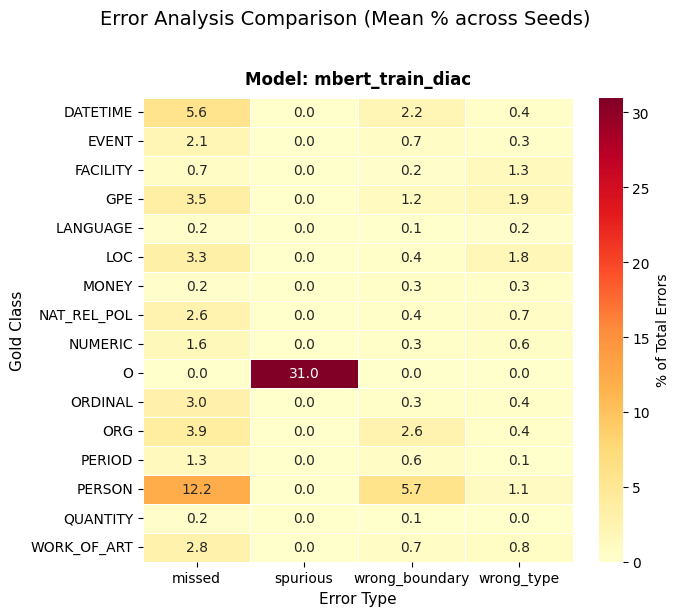

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compute
error_counts = (
    errors.groupby(["run_name", "iteration_no", "gold_class", "error_type"])
    .size()
    .unstack(fill_value=0)
)
total_errors = errors.groupby(["run_name", "iteration_no"]).size()
pct_by_run = error_counts.div(total_errors, axis=0) * 100

# 2. Compute mean across runs for each (model_id, gold_class)
mean_pct = pct_by_run.groupby(["run_name", "gold_class"]).mean()

# 3. Plot side-by-side heatmaps
unique_models = errors["run_name"].unique()
fig, axes = plt.subplots(
    1, len(unique_models), figsize=(7 * len(unique_models), 6), sharey=True
)

# Handle single-model edge case
if len(unique_models) == 1:
    axes = [axes]

for i, model_id in enumerate(unique_models):
    model_data = mean_pct.loc[model_id]

    sns.heatmap(
        model_data,
        annot=True,
        fmt=".1f",
        cmap="YlOrRd",
        cbar_kws={"label": "% of Total Errors"},
        ax=axes[i],
        linewidths=0.5,
    )

    axes[i].set_title(
        f"Model: {model_id}", fontsize=12, fontweight="bold", pad=10
    )
    axes[i].set_xlabel("Error Type", fontsize=11)
    if i == 0:
        axes[i].set_ylabel("Gold Class", fontsize=11)
    else:
        axes[i].set_ylabel("")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/rodi_study/ner_error_analysis/error_analysis_comparison.png", dpi=300, bbox_inches="tight")
plt.show()